In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import re

def format_ticks(value, _):
    if value >= 1e6:
        return f'{int(value / 1e6)}m'
    elif value >= 1e3:
        return f'{int(value / 1e3)}k'
    else:
        return str(int(value))

def parse_log_file(file_path, method):
    """
    file_path: str
    method: "jolt" | "nexus" | "sp1" | "ceno"
    """
    with open(file_path, 'r') as file:
        content = file.read()

    if method == 'jolt':
        proof_duration_match = re.search(r'proof generation took:\s*([\d.]+)(ms|s)', content)
        max_memory_match = re.search(r'Maximum resident set size \(kbytes\):\s*(\d+)', content)
        user_cycles_match = re.search(r'trace len:\s*(\d+)', content)
        if proof_duration_match:
            proof_duration_value = float(proof_duration_match.group(1))
            proof_duration_unit = proof_duration_match.group(2)
            proof_duration_sec = (
                proof_duration_value / 1000 if proof_duration_unit == 'ms' else proof_duration_value
            )
        else:
            proof_duration_sec = None
    if method == 'nexus':
        proof_duration_match = re.search(r'User time \(seconds\):\s*([\d.]+)', content)
        max_memory_match = re.search(r'Maximum resident set size \(kbytes\):\s*(\d+)', content)    
        proof_duration_sec = float(proof_duration_match.group(1)) if proof_duration_match else None
        user_cycles_match = None

    max_memory_kb = int(max_memory_match.group(1)) if max_memory_match else None
    user_cycles = int(user_cycles_match.group(1)) if user_cycles_match else None

    return {
        'file': os.path.basename(file_path),
        'proof_duration_sec': proof_duration_sec,
        'max_memory': max_memory_kb,
        'user_cycles': user_cycles
    }

def parse_ceno_log_file(file_path):
    with open(file_path, 'r') as file:
        content = file.read()

    proof_matches = re.findall(
        r'::create_proof, max_steps = (\d+), time = ([\d.]+), peak_memory = (\d+)', 
        content
    )

    data = []
    for match in proof_matches:
        max_steps = int(match[0])
        time_sec = float(match[1])
        peak_memory = int(match[2])
        data.append({
            'user_cycles': max_steps,  # cycles = max_steps
            'proof_duration_sec': time_sec,
            'max_memory': peak_memory,
        })
    
    df = pd.DataFrame(data)
    grouped_df = df.groupby('user_cycles').mean().reset_index()
    return grouped_df

def parse_multiple_logs(files, method):
    data = []
    for file_name in files:
        file_path = os.path.basename(file_name)
        parsed_data = parse_log_file(file_path, method)
        data.append(parsed_data)
    return pd.DataFrame(data)

# Load RISC0 CSV Files
risc0_fib_csv_file_name = 'RISC0_fibonacci_metrics.csv'
risc0_fib_df = pd.read_csv(risc0_fib_csv_file_name)
risc0_fib_df['proof_duration_sec'] = risc0_fib_df['proof_duration'] / 1e9
risc0_matrix_csv_file_name = 'RISC0_matrix_ops_metrics.csv'
risc0_matrix_df = pd.read_csv(risc0_matrix_csv_file_name)
risc0_matrix_df['proof_duration_sec'] = risc0_fib_df['proof_duration'] / 1e9

# Load Jolt CSV Files
jolt_fib_log_files = ["jolt_fibonacci_n10.log", "jolt_fibonacci_n100.log", 
             "jolt_fibonacci_n1000.log", "jolt_fibonacci_n10000.log", 
             "jolt_fibonacci_n100000.log"]
jolt_fib_df = parse_multiple_logs(jolt_fib_log_files, 'jolt')
jolt_fib_log_files = ["jolt_matrix_ops_n10.log", "jolt_matrix_ops_n20.log", 
             "jolt_matrix_ops_n30.log", "jolt_matrix_ops_n40.log"]
jolt_matrix_df = parse_multiple_logs(jolt_fib_log_files, 'jolt')

# Load Nexus CSV Files
nexus_fib_log_files = ["nexus_fibonacci_n10.log", "nexus_fibonacci_n100.log", 
             "nexus_fibonacci_n1000.log", "nexus_fibonacci_n10000.log", 
             "nexus_fibonacci_n100000.log", "nexus_fibonacci_n1000000.log"]
nexus_fib_df = parse_multiple_logs(nexus_fib_log_files, 'nexus')

# Load Ceno CSV Files
ceno_fib_csv_file_name = 'ceno_fibonacci.log'
ceno_fib_df = parse_ceno_log_file(os.path.basename(ceno_fib_csv_file_name))


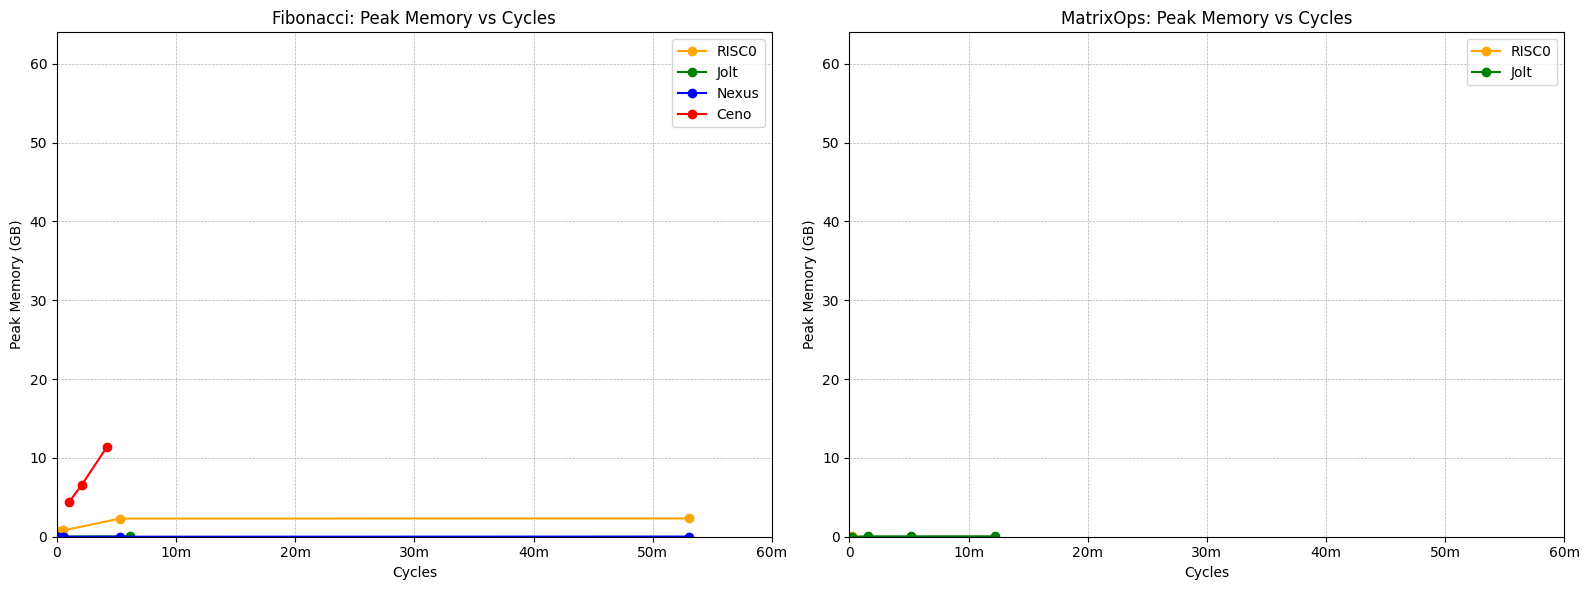

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fibonacci Peak Memory vs Cycles
axes[0].plot(risc0_fib_df['user_cycles'], risc0_fib_df['max_memory'] / 1e9, marker='o', label='RISC0', color='orange')
axes[0].plot(jolt_fib_df['user_cycles'], jolt_fib_df['max_memory'] / 1e9, marker='o', label='Jolt', color='green')
axes[0].plot(risc0_fib_df['user_cycles'], nexus_fib_df['max_memory'] / 1e9, marker='o', label='Nexus', color='blue')
axes[0].plot(ceno_fib_df['user_cycles'], ceno_fib_df['max_memory'] / 1e9, marker='o', label='Ceno', color='red')
axes[0].set_title('Fibonacci: Peak Memory vs Cycles')
axes[0].set_xlabel('Cycles')
axes[0].set_ylabel('Peak Memory (GB)')
# axes[0].set_xscale('log')
axes[0].set_xlim(0, 60000000)
axes[0].set_ylim(0, 64)
axes[0].xaxis.set_major_formatter(FuncFormatter(format_ticks))
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].legend()

# MatrixOps Peak Memory vs Cycles
axes[1].plot(risc0_matrix_df['user_cycles'], risc0_matrix_df['max_memory'] / 1e9, marker='o', label='RISC0', color='orange')
axes[1].plot(jolt_matrix_df['user_cycles'], jolt_matrix_df['max_memory'] / 1e9, marker='o', label='Jolt', color='green')
axes[1].set_title('MatrixOps: Peak Memory vs Cycles')
axes[1].set_xlabel('Cycles')
axes[1].set_ylabel('Peak Memory (GB)')
# axes[1].set_xscale('log')
axes[1].set_xlim(0, 60000000)
axes[1].set_ylim(0, 64)
axes[1].xaxis.set_major_formatter(FuncFormatter(format_ticks))
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [73]:
import json
from collections import defaultdict

# トレースJSONファイルを読み込む
def load_tracing_json(file_path):
    with open(file_path, 'r') as f:
        return json.load(f)

# トレースデータを解析してカテゴリごとの時間を計算
def calculate_time_by_category(trace_data):
    stack = defaultdict(list)  # カテゴリごとのスタック
    total_time_by_cat = defaultdict(float)  # カテゴリごとの合計時間

    for event in trace_data:
        if event["ph"] == "B":  # 開始イベント
            stack[event["cat"]].append(event)
        elif event["ph"] == "E":  # 終了イベント
            if stack[event["cat"]]:  # スタックが空でない場合のみ処理
                start_event = stack[event["cat"]].pop()
                duration = event["ts"] - start_event["ts"]  # 時間差（マイクロ秒）
                total_time_by_cat[event["cat"]] += duration / 1e3  # ミリ秒に変換

    return total_time_by_cat

# 結果を出力
def print_time_by_category(total_time_by_cat):
    print("Category-wise Time (ms):")
    for cat, time in total_time_by_cat.items():
        print(f"{cat}: {time:.3f} ms")

# ファイルパス（適宜変更）
trace_file = "trace-fibonacci.json"

# トレースJSONを読み込み
trace_data = load_tracing_json(trace_file)

# カテゴリごとの時間を計算
total_time_by_cat = calculate_time_by_category(trace_data)

# 結果を表示
print_time_by_category(total_time_by_cat)


Category-wise Time (ms):
jolt_core::host: 227.446 ms
tracer: 30.522 ms
jolt_core::jolt::vm::instruction_lookups: 296.028 ms
jolt_core::jolt::vm::read_write_memory: 44.286 ms
jolt_core::jolt::vm::bytecode: 0.643 ms
jolt_core::msm: 2603.695 ms
jolt_core::jolt::vm: 4245.891 ms
jolt_core::poly::dense_mlpoly: 35.532 ms
jolt_core::jolt::vm::timestamp_range_check: 27.332 ms
jolt_core::r1cs::spartan: 15.723 ms
jolt_core::utils::thread: 34.320 ms
jolt_core::r1cs::inputs: 5.059 ms
jolt_core::r1cs::builder: 3.388 ms
jolt_core::poly::commitment::kzg: 1083.421 ms
jolt_core::subprotocols::grand_product: 237.075 ms
jolt_core::lasso::memory_checking: 580.007 ms
jolt_core::poly::eq_poly: 6.126 ms
jolt_core::utils: 19.849 ms
jolt_core::poly::split_eq_poly: 4.107 ms
jolt_core::poly::dense_interleaved_poly: 198.950 ms
jolt_core::poly::unipoly: 15.135 ms
jolt_core::subprotocols::sumcheck: 238.583 ms
jolt_core::poly::opening_proof: 170.907 ms
jolt_core::subprotocols::sparse_grand_product: 26.373 ms
jolt_cor